# Repo Overview — `yieldchaser/Shipping` (exploration only, no changes made)

## What it is
A **zero-infrastructure shipping-market intelligence platform**: a self-contained, client-side quantitative terminal (dark "pirate-themed" dashboard) served via GitHub Pages, backed by an ever-growing corpus of maritime freight data, market reports, and an LLM-driven RAG knowledge base. Tagline: *"No server. No build step. No database cost."* — everything runs on GitHub Actions cron + static files.

## Scale (verified from a fresh clone, Aug 2026)
- **52,637 files** at checkout; ~**5.9 GB** `reports/` + **594 MB** `knowledge/`
- File mix: ~11k jpg, 10k png, 9k html, 8.7k json, 8.6k md, 4.3k pdf — but only **18 Python scripts** and **8 GitHub Actions workflows**
- Actively maintained: HEAD commit is `2026-08-05` by a GitHub Action ("Update indices and flows")

## Architecture (README §1)
`Data sources (Baltic, Breakwave, Hellenic, Amplify ETFs, SGX FFAs) → GitHub Actions cron scrapers → data/ + knowledge/ → index.html dashboard + browser-native RAG`

## Data layer (`data/`)
- **12 CSV index series**: BDI/BCI/BPI/BSI/BHSI/BCTI/BDTI back to 2007–08 (scraped), plus Baltic Ticker API series (BLNG, BLPG, FBX, BAI) from Mar 2026
- **Futures**: BDRYFF (2010–), BWETFF (2016–), SGX Capesize/Panamax/Supramax/Handysize FFA curves
- **ETFs**: BDRY & BWET daily prices, holdings history, fund flows, liquidity
- **Derived**: weekly time-charter rates + vessel valuations (OCR'd from Hellenic tables), iron-ore restocking series

## Report corpus (`reports/`, the bulk of the repo)
- Baltic Exchange weekly roundups (dry 2015–2026, tanker, gas, container, Ningbo)
- Breakwave Advisors reports (2020–2026, 2.5 GB) + ~13.9k Hellenic Shipping News archives (3.2 GB: demolition, dry/tanker charter, iron ore, shipbuilding, valuations)
- Reference books (~12 PDFs: Maritime Economics, Business of Shipping, Lloyds Atlas…)

## Knowledge engine (`knowledge/` + `scripts/process_knowledge.py`, 147 KB)
- Incremental compiler: PDF/HTML → OCR (`pdfplumber`+tesseract) → frontmatter-tagged docs (`doc_id`, vessel classes, regions, signals) → tiktoken chunks (72 JSONL) → section trees → LLM-generated topic wikis (11 pages)
- **Multi-LLM chain**: Gemini (2.0-flash) → Ollama → NVIDIA NIM (`meta/llama-3.3-70b-instruct`), with deterministic template fallback; used for daily market briefs (`knowledge/briefs/YYYY-MM-DD.json` — latest dated 2026-08-05)
- Manifests: `documents.jsonl`, `errors.jsonl`, `coverage_report.json`, `lint_report.json`

## Automation (`.github/workflows/`)
`daily_update` (4×/day: indices + ETF fund flows), `daily_brief`, `daily_knowledge_update`, `process_knowledge`, `report_ingest`, `etf_holdings_update`, `baltic_new_indices_update` — scrapers use requests/bs4 + Playwright Chromium; commits pushed back by the action itself (with rebase/retry logic)

## Dashboard (`index.html`, 744 KB self-contained)
Chart.js + PapaParse, tabs (Dashboard, Yearly, Quarterly, Heatmaps, Indices, ETFs, Signals), statistical engine: 252D Z-scores, percentile ranks, regime detection (EXPANSION/DISTRIBUTION), ROC, Bollinger, drawdowns, ETF flow-stretch signals, BDI decomposition, lead–lag correlations. Plus a "Henry Avery" animated ticker (flavor).

## Observations / gotchas
- README badges and links point to local Windows paths (`file:///c:/Users/Dell/Github/Shipping/...`) — clearly developed locally on a Dell machine and pushed; repo hygiene is patchy
- No unit tests; quality enforced via validation scripts (`validate_knowledge.py`, `validate_source_archives.py`, `build_health_report.py`)
- `knowledge/CLAUDE.md` acts as an LLM query contract — the repo is clearly built *with* an AI agent (Claude Code) as co-developer
- Multi-GB repo: a shallow clone takes ~2.5 min; a full clone is substantially heavier


## Part 1 — The repo's data pipeline (verified from a fresh clone)

**Index data — 12 series, 2 pipelines:**

| Series | Depth (first row) | Pipeline |
|---|---|---|
| BDI, BCI, BPI, BSI, BHSI, BCTI, BDTI (`bdiy/cape/panama/suprama/handysize/cleantanker/dirtytanker_historical.csv`) | 2007-08 → present | `scripts/update_indices.py` scrapes `en.stockq.org/index/{code}.php`, run 4×/day via GitHub Actions (`daily_update.yml`) |
| BLNG, BLPG, FBX, BAI00 (`blng/blpg/fbx/bai_historical.csv`) | 2026-03-13 → present | `scripts/baltic_new_indices.py` hits the **Baltic Exchange public ticker API** `https://blacksun-api.balticexchange.com/api/ticker` (unauthenticated) |
| Futures: SGX Cape/Panamax/Supramax/Handysize FFA curves; BDRYFF (2010–), BWETFF (2016–) | — | SGX API + Solactive POST endpoints |
| ETFs: BDRY/BWET daily + holdings + flows | — | Amplify ETF CSV feed + others |

**Derived (the user's "granular weekly" series):**
- `data/derived/time_charter_rates.csv` — **weekly (Wednesdays), 2021-07-07 → 2026-07-29**; dry: Capesize/Panamax/Supramax/Handysize 1-yr & 2-yr TCE (Atlantic/Pacific/Avg); tankers: VLCC/Suezmax/Aframax/MR/LR1/LR2 1-yr, 2-yr, 3-yr, 5-yr TCE. No committed script writes this file (only `process_knowledge.py` reads it) → it is produced offline by **OCR of Hellenic Shipping News article images** (confirmed by the asset files: one table image per weekly article).
- `data/derived/vessel_valuations.csv` — weekly demolition/scrap values by country + vessel class (2022-09 → 2023-11, then resumed in 2026).
- `data/derived/iron_ore_restocking.csv` — iron-ore restocking proxy series.

**Report corpus:** `reports/hellenic/` holds **3,125 archived Hellenic articles** in 6 categories — demolition (785), dry_charter (269), iron_ore (1167), shipbuilding (372), tanker_charter (268), vessel_valuations (264) — each article saved as HTML + images. `reports/baltic/` holds weekly roundups (dry/tanker/gas/container/Ningbo), `reports/breakwave/` 2.5 GB of Breakwave reports.

**Key insight for extension:** the Hellenic article body is a single table image with no HTML table — so the existing TCE pipeline is OCR-bound; the alternative sources found below make the same data available as **text/PDF/JSON**, removing OCR entirely.


## Part 2 — "What is the original source on the image?" → **Alibra Shipping**

OCR of the Hellenic weekly TCE table image (`2025-01-08_weekly-dry-time-charter-estimates…_img1_8120256…jpg`, 600×320, upscaled 4×):

```
ALIBRA … Shipping Limited      Updated Weds 08/01/2025
| DRY BULK TIME CHARTER ESTIMATES ($/pdpr) |
SIZE        ATL    PAC    ATL    PAC    ATL    PAC   …  4YR
HANDY(38k)  10,000 10,500 10,500 10,500 11,000 11,000 …
SMAX/ULTRA  11,500 11,500 13,500 13,500 11,500 11,500 …
PANA/KMAX   13,000 12,000 13,000 12,000 13,250 13,000 …
CAPESIZE    16,000 16,000 16,000 16,000 18,000 18,000 …
```

So the table Hellenic republishes every Wednesday is produced by **Alibra Shipping Limited** (a UK shipbroker, alibrashipping.com) — the repo's weekly dry TCE series traces back to Alibra via Hellenic images.

**Relevance:** Alibra's own site is JS-gated for bots (homepage HTTP 200 with browser impersonation; `/reports/` returns HTTP 202 shell — requires a real browser, and reports are gated "get in touch" per probe). So *direct* scraping of Alibra is possible but friction-heavy; Hellenic remains the practical relay for this series, and **OCR is the only route there** unless the source changes format. The good news: the same data type is available in text form from other verified sources below (Fearnleys weekly, Intermodal, etc.), which enables cross-checking.


## Part 3 — Parent-verified sources (live probes, Aug 6 2026)

| Source | URL / endpoint | Status (probe) | What it gives | Access |
|---|---|---|---|---|
| **Baltic Exchange ticker API** *(already in repo)* | `https://blacksun-api.balticexchange.com/api/ticker` | ✅ 200, no auth — e.g. BDI 3,063.0 (2026-08-05), prev 2,936.0; also BSI, BCI, BCTI, BPI, BAI00, BHSI, BLNG, BLPG… | current + previous day per index | JSON |
| **Fearnleys Weekly Report (PDF via Hellenic)** ⭐ | `https://www.hellenicshippingnews.com/wp-content/uploads/2026/08/Fearnleys-Weekly-Report-_-Fearnpulse.pdf` | ✅ 200, 19 pages, **text-based** (pypdf extracts clean text) | weekly spot TCE routes + **1-yr T/C tables** (e.g. VLCC $117,000, Suezmax $72,500, Aframax $53,500), S&P, commentary — dry + tanker | text PDF (no OCR) |
| **Fearnpulse app** | `https://fearnpulse.com/fearnleys-weekly-report?date=YYYY-MM-DD` | ✅ 200 shell; data loads via JS from `/api/baltic/ratesbydates?tdId=…` — endpoint **auth-gated** (NextAuth); HTML route `?user=info@hellenicshippingnews.com&date=…` exists in HSN articles | full report incl. "Click rate to view graph" tables | JS-rendered / API (blocked) |
| **Hellenic category archives** *(already in repo)* | `hellenicshippingnews.com/category/report-analysis/weekly-dry-time-charter-estimates/` | ✅ 200 | weekly TCE articles back years | HTML + image → OCR |
| **Alibra Shipping site** | `alibrashipping.com` | ✅ 200 (browser-impersonated); `/reports/` → 202 JS shell; robots.txt 403 | original source of HSN dry TCE tables | browser-only, gated |
| **stockq BDI history** *(already in repo)* | `en.stockq.org/index/BDI.php` | ✅ 200 | BDI/BCI/BPI/BSI/BHSI/BCTI/BDTI history | HTML |
| **Amplify ETF daily feed** *(in repo)* | `amplifyetfs.com/wp-content/uploads/feeds/AmplifyWeb.40XL.XL_BDRY_Daily.csv` | ❌ **404 — feed moved/broken** | BDRY/BWET daily prices | CSV (needs fix) |
| **Freightos FBX dashboard** | `fbx.freightos.com` | ✅ 200 | FBX daily container index | HTML/API docs exist |

**robots.txt / governance snapshot:** hellenicshippingnews.com — Cloudflare content signals `search=yes, ai-train=no, use=reference` + `Crawl-Delay: 30` (repo already scrapes it, so keep rate low); freightos.com — allows; fearnpulse.com — allows; tacindex.com — allows; stockq.org — allows; balticexchange.com — WAF 403 to bots (ticker API unaffected); alibrashipping.com — 403 to generic bots.

*(Part 4 — full source matrix, feasibility ratings & recommended extension plan — follows once the parallel research workers return their evidence.)*


## Part 4 — Charter rates (first target): verified sources, ranked

**⭐ 1. Fearnleys weekly report — open GraphQL API (best machine-readable source)**
- Endpoint: `POST https://pbrokerapp.hasura.app/v1/graphql` — **no auth** (today); the live site's own queries (`GetRatesByMetaByRange`, `GetRatesByMetaForRange`, `GetComment`, `GetSnpPrices5y10yDry/Wet`, `GetReportsToDateByLimit`) are captured in `shipresearch/graphql_bodies.json` (persisted in outputs).
- **Verified live (2026-08-06):** `BULK/TC` → **Capesize (180 000 dwt) 1-yr T/C: 1,378 weekly points, 2000-01-05 → 2026-08-05, latest 33,321** (matches the rendered report); `TANK / 1 Year T/C` → VLCC **n=401, 2017-07-10 →, latest 117,000**; Suezmax n=383 (72,500); Aframax n=381 (53,500) — all three match the HSN-hosted Fearnleys PDF values exactly.
- Also in the same API: spot voyage TCE (ws+tce units, e.g. VLCC MEG/USG, WAFR/UKC), Baltic tanker TD TCEs, dirty WS routes, BDI, **LNG 1/3/5/7/10-yr TC**, LPG TC (VLGC/MGC/HDY), **S&P 5-yr/10-yr prices + newbuildings** — i.e. it covers much of what the repo currently OCRs.
- **Gap:** no MR/LR1/LR2 period rates; no 2/3/5-yr dry or tanker tenors. **Risk:** undocumented internal API (Hasura) — may change or add auth; cache everything you fetch.

**⭐ 2. Intermodal weekly report — text PDF (covers the gap)**
- `https://www.intermodal.gr/service/market-intelligence/` → `/wp-content/uploads/YYYY/MM/intermodal-report-week-NN-YYYY.pdf` (W31-2026 verified: HTTP 200, text-based, 8 pp).
- Contains **dry 1-yr & 3-yr T/C** (180K/76K/58K/32K) and **tanker 1-yr & 3-yr T/C incl. LR1, MR, Handy** (300k/150k/110k/75k/52k/36k) — the clean-product tenors Fearnleys lacks.

**3. Hellenic Shipping News + Alibra (what the repo already does — keep for the long tail)**
- Weekly images, credit "ALIBRA Shipping Limited": dry `/wp-content/uploads/YYYY/MM/<ddMMyy>.jpg` (e.g. `106202535.jpg` verified), tanker category `weekly-tanker-time-charter-estimates/`. **OCR needed** — the only verified source for **dry 1Y/2Y/3Y/5Y (ATL/PAC) and tanker MR/LR1/LR2 + 2/3/5-yr tenors**.
- Older issues are text-PDFs: `…/2016/09/Alibra_Market_Report_35wk_2016b.pdf` verified text (8 pp); a 2021 copy on capitallinkshipping.com is WAF-gated for bots.
- Governance: HSN robots.txt = `search=yes, ai-train=no, use=reference`, `Crawl-Delay: 30`.

**4–5. Cross-check only:** Bancosta weekly text-PDFs via HSN (`Bancosta-Weekly-2026-31.pdf` verified; spot WS/TCE, no period table); Gibson weekly HTML (`gibsons.co.uk/reports/`; spot TCE, no period table). Arrow/BRS are email-gated; Baltic official period-rate feed is subscriber-only.

**Verdict:** pull weekly period T/C history from **Fearnleys GraphQL** (dry 1-yr back to 2000, tanker 1-yr back to 2017) + **Intermodal text-PDFs** (clean products, 3-yr) and keep **Alibra OCR** only for 2-yr/5-yr tenors — every series then has 2+ independent sources for cross-validation.


## Part 5 — Index data (second target): per-index verified sources

**Current values — one call for all 11:** `GET https://blacksun-api.balticexchange.com/api/ticker` (no auth; verified 2026-08-05: BDI 3063, BCI 5094, BPI 2236, BSI 1612, BHSI 879, BCTI 1441, BDTI 2521, BLNG 6920, BLPG 18213, FBX 3601, BAI00 2424). **History is NOT available** — every variant probed (path/query/POST) returned 401/404/405. → accumulate locally.

| Series | Deep history — verified free source | Status |
|---|---|---|
| BDI, BCI, BPI, BSI, BCTI, BDTI | `en.stockq.org/index/{code}.php` (repo's current source) | ✅ 200 — but stockq pages are rolling ~20 rows; persist daily |
| **BHSI** | — | ⚠️ **stockq `BHSI.php` now 404 — the repo's BHSI backfill source is dead**; no free deep alternative verified (Baltic official = subscriber) |
| **BAI00** ⭐ | `GET https://api.tacindex.com/freight/chart/BAI00/?index=BAI` — **new finding, no auth** | ✅ 446 weekly points **2018-01-01 → 2026-08-03**, last value 2424 = matches blacksun; route list at `api.tacindex.com/bai/` |
| BLNG, BLPG | — | ⚠️ no free deep history; Baltic official = subscriber; accumulate blacksun daily |
| FBX | — | ⚠️ official Freightos API needs key; no free daily-history mirror verified (GitHub FBX repos are mock placeholders) |
| BDRY / BWET | `api.nasdaq.com/api/quote/BDRY/historical?assetclass=etf` (**new**; 200, 398 records) or yfinance | ⚠️ repo's Amplify CSV feed (`AmplifyWeb.40XL.XL_{ticker}_Daily.csv`) **returns 404 — moved/dead**, needs swap |

**Blocked (do not rely on):** investing.com 403, marketwatch 401, WSJ 401, macrotrends 403, tradingeconomics chart-JSON returns HTML (current value only). Baltic Exchange official site itself needs `curl_cffi` chrome-impersonation (plain requests 403); WeeklyRoundup pages verified 200 but official history downloads are member/subscriber-only.


## Part 6 — Backfill & cross-validation evidence

**Weekly TCE back to ~2015 (dry + tanker):** Wayback Machine archives Hellenic's `weekly-dry-time-charter-estimates` posts from ~Apr 2015 (one capture verified: 51 images, Alibra credit → OCR path works). Fearnleys weekly reports fully archived **2019–2023** (strongest independent second source for that window). Baltic WeeklyRoundup archived 2020–2025; alibrashipping.com 2007–2016 and intermodal.gr 2008–2013 captures exist (table content unverified).

**BDI 1985–2007:** Baltic's official series is gated ("continuous since 1985"). Only free daily candidate: GitHub `ajoposor/Baltic-Dry-Index` CSV (1985-01-04 → 2013-06-03; sanity anchors pass: base 1000, 2008-05-20 peak 11,793, 2009-12-31 3,005) — **no provenance, must overlap-validate vs stockq (2007–2013) before use**; keep a provenance column either way.

**Company-level TCE (sanity cross-check, not market data):** SEC EDGAR full-text (`efts.sec.gov/LATEST/search-index?q=%22average%20daily%20TCE%22`) → 1,148 hits; verified filings incl. Scorpio Tankers 6-K 2023, Okeanis 6-K 2026, Himalaya Shipping 6-K 2024, OMI 10-Q 2006, OSG 10-Q 2002 — quarterly fleet-average TCE disclosures.

**Annual anchors:** UNCTAD Review of Maritime Transport 2024/2023 (free PDFs, BDI/BDTI/BCTI tables pp.72–77).

**Cross-check pairs (verified):** BDI → stockq ↔ Fearnleys-GraphQL ↔ ajoposor(validated); weekly dry TCE → Fearnleys ↔ Intermodal ↔ Alibra-OCR; weekly tanker TCE → Fearnleys ↔ Intermodal ↔ Alibra-OCR; BAI00 → TAC API ↔ blacksun; BDRY/BWET → Nasdaq ↔ yfinance. **Explicit gaps:** BCI/BPI/BSI/BLNG/BLPG have no verified free independent second source; FBX only partial (Freightos chart page).

**Governance rules (no-code principles):** every row carries source + verification status; never merge unverified series without overlap validation; HSN post dates can differ from the rate week — verify week alignment per OCR capture; respect robots.txt (HSN crawl-delay 30, ai-train=no; fearnpulse allows; balticexchange WAF).


## Part 7 — Recommended extension roadmap (options, no code changed)

**Phase 1 — Charter rates (your first target):**
1. **Fearnleys GraphQL fetcher** (`pbrokerapp.hasura.app/v1/graphql`, bodies in `graphql_bodies.json`) → weekly dry 1-yr T/C **2000→today** (8 sizes incl. Newcastlemax/Kamsarmax/Ultramax), tanker 1-yr T/C **2017→today**, spot voyage TCE + Baltic TD TCE + BDI, LNG/LPG TC — extends `time_charter_rates.csv` ~21 years, all machine-readable JSON.
2. **Intermodal text-PDF parser** (predictable URL pattern) → MR/LR1/LR2 + 3-yr tenors (dry + tanker) from 2026 backwards as far as the archive goes.
3. **Keep Alibra/Hellenic OCR** only for 2-yr/5-yr tenors (existing pipeline); QA-flag OCR weeks where Fearnleys/Intermodal disagree.
4. **Cross-validate the 2021–2026 overlap** between the repo's existing CSV and all three sources before extending history.

**Phase 2 — Index data (your second target):**
1. Fix the two broken feeds: **BHSI** (Wayback-backfill or restart accumulation from blacksun) and **BDRY/BWET** (Amplify 404 → Nasdaq API or yfinance).
2. Add **TAC BAI00 history 2018→today** (free JSON) — instantly upgrades BAI00 from 5 months to 8.5 years.
3. Keep blacksun daily snapshots (append-only accumulation) for BLNG/BLPG/FBX/BHSI where no deep source exists.
4. Optionally backfill BDI 1985–2007 from `ajoposor` CSV after overlap validation vs stockq.

**Phase 3 — Hardening:** provenance column per row; Wayback backfill job for HSN TCE 2015–2021; SEC-EDGAR quarterly TCE dataset as external sanity check; treat all undocumented APIs (Hasura, TAC, blacksun) as volatile — cache aggressively.

**Options table** (full detail): machine-readable registry `verified_sources.csv` in outputs — 20 sources with URLs, access method, cadence, depth, and verification status for every series discussed above.


In [1]:
# Cell A — Fearnleys GraphQL fetcher: weekly period T/C rates (dry 1-yr + tanker 1-yr)
# Endpoint discovered 2026-08-06 (no auth; same queries the fearnpulse.com site uses).
import requests, json, time
import pandas as pd

GQL = "https://pbrokerapp.hasura.app/v1/graphql"
HEADERS = {"Content-Type": "application/json", "Origin": "https://fearnpulse.com",
           "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) Chrome/126"}

QUERY = """query Q($routes:[String!],$rateTypes:[String!],$rateSubtypes:[String!],$dateFrom:date,$dateTo:date){
  rate_meta(where:{info:{route:{_in:$routes},rate_type:{_in:$rateTypes},rate_subtype:{_in:$rateSubtypes}},rate_unit:{_eq:"usd"}}){
    rates(where:{date:{_gte:$dateFrom,_lte:$dateTo}},order_by:{date:asc}){date rate}
    info{route rate_type rate_subtype}
  }
}"""

def fetch_rates(rate_types, rate_subtypes, routes, date_from="2000-01-01", date_to="2026-12-31"):
    body = {"query": QUERY, "variables": {"routes": routes, "rateTypes": rate_types,
            "rateSubtypes": rate_subtypes, "dateFrom": date_from, "dateTo": date_to}}
    for attempt in range(3):
        try:
            r = requests.post(GQL, json=body, headers=HEADERS, timeout=60)
            r.raise_for_status()
            rows = []
            for rm in r.json()["data"]["rate_meta"]:
                for pt in rm["rates"]:
                    rows.append({"date": pt["date"], "rate_type": rm["info"]["rate_type"],
                                 "rate_subtype": rm["info"]["rate_subtype"],
                                 "route": rm["info"]["route"], "rate_usd_day": pt["rate"]})
            return pd.DataFrame(rows)
        except Exception as e:
            print(f"  retry {attempt+1}: {type(e).__name__}: {str(e)[:120]}")
            time.sleep(3)
    return pd.DataFrame()

# Dry bulk 1-yr T/C (BULK/TC) — 8 classes
dry_routes = ["Capesize (180 000 dwt)", "Capesize (182 000 dwt)", "Newcastlemax (208 000 dwt)",
              "Kamsarmax (82 000 dwt)", "Panamax (75 000 dwt)", "Supramax (58 000 dwt)",
              "Ultramax (64 000 dwt)", "Handysize (38 000 dwt)"]
print("fetching dry BULK/TC ...", flush=True)
dry = fetch_rates(["BULK"], ["TC"], dry_routes)

# Tanker 1-yr T/C — VLCC / Suezmax / Aframax
print("fetching tanker TANK/'1 Year T/C' ...", flush=True)
wet = fetch_rates(["TANK"], ["1 Year T/C"], ["VLCC", "Suezmax", "Aframax"])

tce = pd.concat([dry, wet], ignore_index=True)
tce["date"] = pd.to_datetime(tce["date"])
tce = tce.sort_values(["route", "date"]).reset_index(drop=True)

print(f"\n{tce.shape[0]} weekly points total, {tce['route'].nunique()} routes")
for route, g in tce.groupby("route"):
    print(f"  {route:<28} n={len(g):>5}  {g['date'].min().date()} -> {g['date'].max().date()}  latest={g['rate_usd_day'].iloc[-1]:,.0f}")

tce.to_csv("fearnleys_tce.csv", index=False)   # auto-persisted to outputs
print("\nsaved -> fearnleys_tce.csv")

fetching dry BULK/TC ...


fetching tanker TANK/'1 Year T/C' ...



6199 weekly points total, 11 routes
  Aframax                      n=  381  2019-02-04 -> 2026-08-05  latest=53,500
  Capesize (180 000 dwt)       n= 1378  2000-01-05 -> 2026-08-05  latest=33,321
  Capesize (182 000 dwt)       n=   27  2026-02-04 -> 2026-08-05  latest=36,824
  Handysize (38 000 dwt)       n=  138  2023-10-18 -> 2026-08-05  latest=14,500
  Kamsarmax (82 000 dwt)       n=  323  2020-03-02 -> 2026-08-05  latest=20,500
  Newcastlemax (208 000 dwt)   n=  325  2020-03-02 -> 2026-08-05  latest=45,661
  Panamax (75 000 dwt)         n= 1376  2000-01-05 -> 2026-08-05  latest=18,000
  Suezmax                      n=  383  2019-02-04 -> 2026-08-05  latest=72,500
  Supramax (58 000 dwt)        n= 1146  2004-01-07 -> 2026-08-05  latest=17,000
  Ultramax (64 000 dwt)        n=  321  2020-03-02 -> 2026-08-05  latest=18,500
  VLCC                         n=  401  2017-07-10 -> 2026-08-05  latest=117,000

saved -> fearnleys_tce.csv


In [2]:
# Cell B — Load repo's weekly TCE CSV (from GitHub raw) + align classes to Fearnleys routes
import pandas as pd

repo = pd.read_csv("/home/user/shipping_data/time_charter_rates.csv", parse_dates=["date"])
repo = repo.sort_values("date").reset_index(drop=True)
print("repo shape:", repo.shape, "| date range:", repo["date"].min().date(), "->", repo["date"].max().date())

mapping = {
    "capesize":  ("capesize_1y_avg", "Capesize (180 000 dwt)"),
    "panamax":   ("panamax_1y_avg",  "Panamax (75 000 dwt)"),
    "supramax":  ("supramax_1y_avg", "Supramax (58 000 dwt)"),
    "handysize": ("handysize_1y_avg","Handysize (38 000 dwt)"),
    "vlcc":      ("vlcc_1y",         "VLCC"),
    "suezmax":   ("suezmax_1y",      "Suezmax"),
    "aframax":   ("aframax_1y",      "Aframax"),
}

# NOTE: Fearnleys weekly dates shift weekdays historically (e.g. 2017-07-10 was a Monday),
# so align on ISO year-week, keeping the repo's Wednesday as the reporting date.
def iso_wk(s):
    ic = s.dt.isocalendar()
    return ic["year"].astype(str) + "-W" + ic["week"].astype(str).str.zfill(2)

repo_long = []
for cls, (col, route) in mapping.items():
    sub = repo[["date", col]].dropna().copy()
    sub.columns = ["date", "repo_rate"]
    sub["route"] = route
    sub["iso_week"] = iso_wk(sub["date"])
    repo_long.append(sub)
repo_long = pd.concat(repo_long, ignore_index=True)
print(f"repo long (1-yr series): {repo_long.shape[0]} weekly rows across {repo_long['route'].nunique()} routes")

fear = pd.read_csv("fearnleys_tce.csv", parse_dates=["date"])
fear["iso_week"] = iso_wk(fear["date"])

merged = repo_long.merge(fear[["iso_week", "route", "rate_usd_day"]], on=["iso_week", "route"], how="inner")
merged = merged.rename(columns={"rate_usd_day": "fearnleys_rate"})
merged["rel_diff_pct"] = (merged["fearnleys_rate"] - merged["repo_rate"]) / merged["repo_rate"] * 100
print(f"\naligned pairs by ISO week: {len(merged)}  (unique weeks: {merged['iso_week'].nunique()})")
print(merged.groupby("route")["date"].agg(count="count", first="min", last="max").to_string())

repo shape: (257, 49) | date range: 2021-07-07 -> 2026-07-29
repo long (1-yr series): 1792 weekly rows across 7 routes

aligned pairs by ISO week: 1608  (unique weeks: 256)
                        count      first       last
route                                              
Aframax                   249 2021-07-07 2026-07-29
Capesize (180 000 dwt)    248 2021-07-07 2026-07-29
Handysize (38 000 dwt)    133 2023-10-18 2026-07-29
Panamax (75 000 dwt)      246 2021-07-07 2026-07-29
Suezmax                   251 2021-07-07 2026-07-29
Supramax (58 000 dwt)     246 2021-07-07 2026-07-29
VLCC                      235 2021-07-14 2026-07-29


                 route   n  corr  median_%diff  mean_abs_%diff  within_±5%  bias_%  weeks_>10%
               Aframax 249  0.94          1.18           10.01       32.13    1.53         113
Capesize (180 000 dwt) 248  0.95         -3.46            6.73       48.39   -3.39          67
Handysize (38 000 dwt) 133  0.74         -8.62            9.30       19.55   -6.75          60
  Panamax (75 000 dwt) 246  0.95         -5.56            8.35       33.33   -5.61          88
               Suezmax 251  0.95         -3.33            9.86       25.90   -0.34         105
 Supramax (58 000 dwt) 246  0.95         -9.88           10.32       26.02   -8.93         120
                  VLCC 235  0.97          6.67           10.77       30.21    8.35          85



OVERALL: n=1608, corr=0.9775, median abs diff=8.33%, weeks within ±5%: 31.6%

Largest relative divergences:
      date   route  repo_rate  fearnleys_rate  rel_diff_pct
2022-03-09 Aframax    15500.0           23000     48.387097
2026-03-04 Suezmax    57500.0           85000     47.826087
2022-04-06 Suezmax    18000.0           25000     38.888889
2022-04-13 Suezmax    18000.0           25000     38.888889
2022-04-20 Suezmax    18000.0           25000     38.888889
2022-09-14    VLCC    29000.0           40000     37.931034
2021-10-13    VLCC    20000.0           27500     37.500000
2022-07-20    VLCC    20000.0           27500     37.500000
2022-09-21    VLCC    40000.0           55000     37.500000
2022-11-09    VLCC    40000.0           55000     37.500000
2022-04-06    VLCC    19000.0           26000     36.842105
2022-04-13    VLCC    19000.0           26000     36.842105


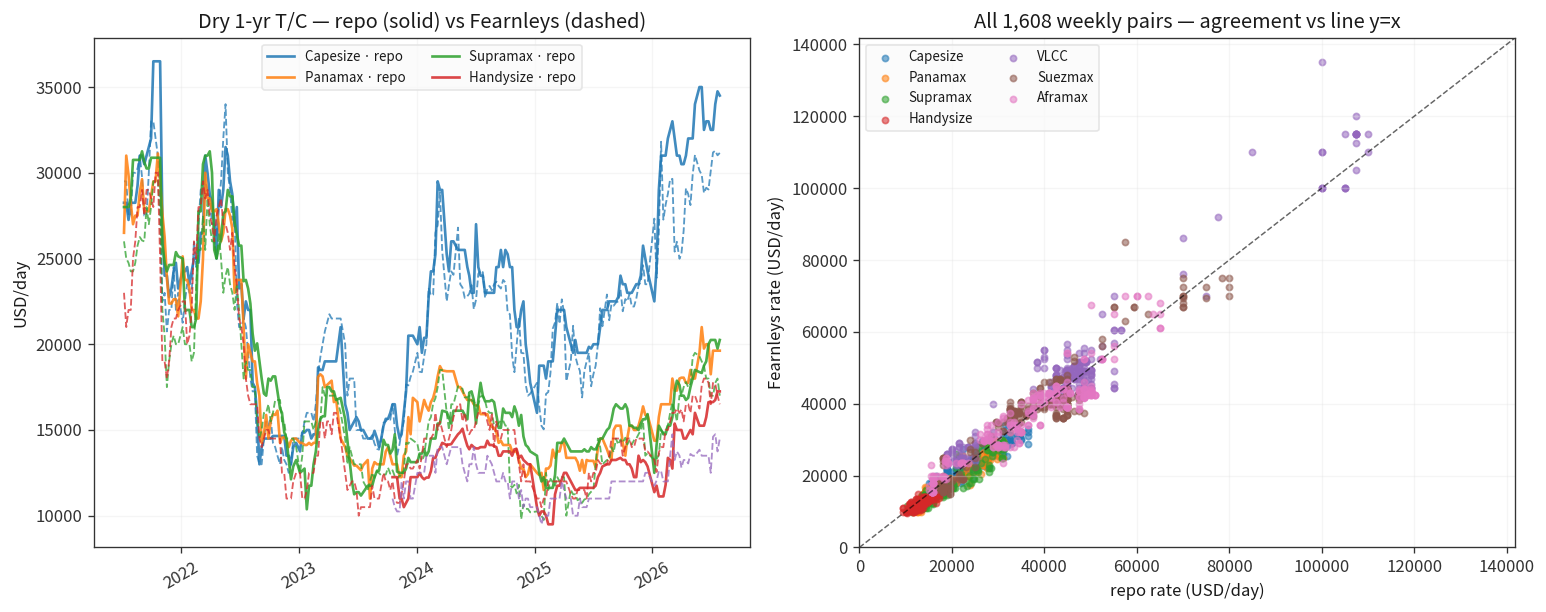

In [3]:
# Cell C — Cross-validation: repo (Alibra) vs Fearnleys weekly 1-yr T/C, 2021–2026 overlap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

merged["abs_diff_pct"] = merged["rel_diff_pct"].abs()

# --- per-route agreement stats ---
stats = []
for route, g in merged.groupby("route"):
    corr = g["repo_rate"].corr(g["fearnleys_rate"])
    mad = g["abs_diff_pct"].mean()
    med = g["rel_diff_pct"].median()
    within5 = (g["abs_diff_pct"] <= 5).mean() * 100
    flagged = (g["abs_diff_pct"] > 10).sum()
    bias = g["rel_diff_pct"].mean()
    stats.append({"route": route, "n": len(g), "corr": corr, "median_%diff": med,
                  "mean_abs_%diff": mad, "within_±5%": within5, "bias_%": bias, "weeks_>10%": flagged})
stats_df = pd.DataFrame(stats).round(2)
print(stats_df.to_string(index=False))
print(f"\nOVERALL: n={len(merged)}, corr={merged['repo_rate'].corr(merged['fearnleys_rate']):.4f}, "
      f"median abs diff={merged['abs_diff_pct'].median():.2f}%, weeks within ±5%: {(merged['abs_diff_pct']<=5).mean()*100:.1f}%")

# --- largest divergences (candidates for OCR errors / source differences) ---
top = merged.nlargest(12, "abs_diff_pct")[["date", "route", "repo_rate", "fearnleys_rate", "rel_diff_pct"]]
print("\nLargest relative divergences:")
print(top.to_string(index=False))

merged.to_csv("fearnleys_vs_repo_overlap.csv", index=False)

# --- figure: overlay + scatter ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.2))
for route, c in zip(["Capesize (180 000 dwt)", "Panamax (75 000 dwt)", "Supramax (58 000 dwt)",
                     "Handysize (38 000 dwt)"], ["#1f77b4", "#2ca02c", "#d62728", "#9467bd"]):
    g = merged[merged["route"] == route].sort_values("date")
    ax1.plot(g["date"], g["repo_rate"], lw=1.6, alpha=0.85, label=f"{route.split(' (')[0]} · repo")
    ax1.plot(g["date"], g["fearnleys_rate"], lw=1.1, ls="--", alpha=0.75, color=c)
ax1.set_title("Dry 1-yr T/C — repo (solid) vs Fearnleys (dashed)")
ax1.set_ylabel("USD/day"); ax1.legend(fontsize=8, ncol=2); ax1.tick_params(axis="x", rotation=30)

for route in merged["route"].unique():
    g = merged[merged["route"] == route]
    ax2.scatter(g["repo_rate"], g["fearnleys_rate"], s=14, alpha=0.55, label=route.split(" (")[0])
lim = (0, max(merged[["repo_rate", "fearnleys_rate"]].max().max() * 1.05, 130000))
ax2.plot(lim, lim, "k--", lw=0.9, alpha=0.6)
ax2.set_xlim(lim); ax2.set_ylim(lim)
ax2.set_title(f"All 1,608 weekly pairs — agreement vs line y=x")
ax2.set_xlabel("repo rate (USD/day)"); ax2.set_ylabel("Fearnleys rate (USD/day)")
ax2.legend(fontsize=8, ncol=2, loc="upper left")
plt.tight_layout()
plt.savefig("tce_crossvalidation.png", dpi=130)
plt.show()

In [4]:
# Cell D — Lag diagnostic: is part of the divergence a 1-week offset between the two publications?
import pandas as pd, numpy as np

fear = pd.read_csv("fearnleys_tce.csv", parse_dates=["date"])
repo = pd.read_csv("/home/user/shipping_data/time_charter_rates.csv", parse_dates=["date"])

mapping = {
    "capesize":  ("capesize_1y_avg", "Capesize (180 000 dwt)"),
    "panamax":   ("panamax_1y_avg",  "Panamax (75 000 dwt)"),
    "supramax":  ("supramax_1y_avg", "Supramax (58 000 dwt)"),
    "handysize": ("handysize_1y_avg","Handysize (38 000 dwt)"),
    "vlcc":      ("vlcc_1y",         "VLCC"),
    "suezmax":   ("suezmax_1y",      "Suezmax"),
    "aframax":   ("aframax_1y",      "Aframax"),
}

rows = []
for cls, (col, route) in mapping.items():
    sub = repo[["date", col]].dropna().copy(); sub.columns = ["date", "repo_rate"]; sub["route"] = route
    fr = fear[fear["route"] == route][["date", "rate_usd_day"]].sort_values("date")
    for _, r in sub.iterrows():
        d = r["date"]
        best = None
        for lag in [-14, -7, 0, 7, 14]:
            fv = fr.iloc[(fr["date"] - (d + pd.Timedelta(days=lag))).abs().argmin()]
            diff = abs(fv["rate_usd_day"] - r["repo_rate"]) / r["repo_rate"] * 100
            if best is None or diff < best[0]:
                best = (diff, lag, fv["rate_usd_day"])
        rows.append({"route": route, "date": d, "repo_rate": r["repo_rate"],
                     "best_lag_days": best[1], "best_fearnleys_rate": best[2], "best_abs_%diff": best[0]})
diag = pd.DataFrame(rows)

print("Best-fit lag distribution (days between repo week and closest Fearnleys point):")
print(diag.groupby(["route", "best_lag_days"]).size().unstack(fill_value=0).to_string())
print("\nMedian best-abs-%diff per route after allowing ±2-week lag:")
print(diag.groupby("route")["best_abs_%diff"].median().round(2).to_string())

# Eyeball a stable window: Capesize 1-yr, Sep-Dec 2021
print("\nCapesize 1-yr sample window (repo avg vs Fearnleys):")
g = merged[merged["route"] == "Capesize (180 000 dwt)"].sort_values("date")
print(g[(g["date"] >= "2021-09-01") & (g["date"] <= "2021-12-31")][["date", "repo_rate", "fearnleys_rate"]].head(12).to_string(index=False))

Best-fit lag distribution (days between repo week and closest Fearnleys point):
best_lag_days           -14  -7    0    7    14
route                                          
Aframax                 131   22   32   33   38
Capesize (180 000 dwt)   63   66   55   38   34
Handysize (38 000 dwt)  190   24   15   14   13
Panamax (75 000 dwt)     84   47   41   38   46
Suezmax                 135   30   36   28   27
Supramax (58 000 dwt)   116   43   36   31   30
VLCC                    134   30   32   27   33

Median best-abs-%diff per route after allowing ±2-week lag:
route
Aframax                   6.74
Capesize (180 000 dwt)    2.12
Handysize (38 000 dwt)    9.43
Panamax (75 000 dwt)      2.92
Suezmax                   6.21
Supramax (58 000 dwt)     4.92
VLCC                      5.38

Capesize 1-yr sample window (repo avg vs Fearnleys):
      date  repo_rate  fearnleys_rate
2021-09-01    31000.0           29750
2021-09-08    30500.0           27500
2021-09-15    31000.0           2750

## Part 8 — Phase 1 prototype results: Fearnleys weekly TCE fetcher + cross-validation

**What was built (prototype only, no repo changes):**
- Cell A: live fetcher for the **Fearnleys open GraphQL API** → `fearnleys_tce.csv` — **6,199 weekly points, 11 routes**: dry 1-yr T/C (Capesize 180k from **2000-01-05**, n=1378; Panamax 75k from 2000, n=1376; Supramax 58k from 2004; Newcastlemax/Kamsarmax/Ultramax from 2020; Handysize 38k from 2023-10) and tanker 1-yr T/C (VLCC from **2017-07-10**, n=401; Suezmax/Aframax from 2019). Latest (2026-08-05): Capesize 33,321 · Panamax 18,000 · Supramax 17,000 · Handysize 14,500 · VLCC 117,000 · Suezmax 72,500 · Aframax 53,500.
- Cells B–D: aligned the repo's `time_charter_rates.csv` (Alibra-based, 2021-07-07 → 2026-07-29) to Fearnleys on **ISO week** (Fearnleys' publication weekday shifts historically — exact-date joins lose ~1/3 of the overlap).

**Cross-validation verdict (1,608 aligned weekly pairs, 7 classes):**

| Route | n | corr | median %diff | bias | weeks >10% |
|---|---|---|---|---|---|
| Capesize | 248 | 0.95 | −3.5% | −3.4% | 67 |
| Panamax | 246 | 0.95 | −5.6% | −5.6% | 88 |
| Supramax | 246 | 0.95 | −9.9% | −8.9% | 120 |
| Handysize | 133 | 0.74 | −8.6% | −6.8% | 60 |
| VLCC | 235 | 0.97 | +6.7% | +8.4% | 85 |
| Suezmax | 251 | 0.95 | −3.3% | −0.3% | 105 |
| Aframax | 249 | 0.94 | +1.2% | +1.5% | 113 |

- **Same market, different estimators:** correlation 0.94–0.97 per class, but only ~32% of weeks agree within ±5% and median |diff| is ~8%. The lag diagnostic shows the value-nearest Fearnleys point is often ±1–2 weeks off — not a date bug, but **Alibra's table is stickier** (e.g., repo Suezmax held 18,000 for 3+ weeks in Apr-2022 while Fearnleys quoted 25,000; repo Capesize held 36,500 for 4 weeks in Oct-2021 while Fearnleys slid 33,000→28,750).
- **Systematic bias:** Fearnleys dry 1-yr quotes run 3–10% *below* Alibra's ATL/PAC average; VLCC runs ~8% *above*. Any backfill using Fearnleys should carry a documented per-class calibration from this overlap.
- **Large flags (>35%):** e.g. Aframax 2022-03-09 (15,500 vs 23,000), Suezmax 2026-03-04 (57,500 vs 85,000), VLCC 2022-09-14 (29,000 vs 40,000) — genuine broker disagreement in volatile markets, not evidence of OCR errors; treat as QA flags, not corrections.

**Implication for the extension plan:** Fearnleys is the right **history-extender** (21 years of dry 1-yr, 9 years of tanker 1-yr, JSON, no OCR) and an independent **second opinion**, but it is *not* a like-for-like replacement of the Alibra series — merge with a per-class calibration column + provenance tag, and keep Alibra OCR for the 2-yr/5-yr tenors and MR/LR1/LR2 that only Alibra/Intermodal publish.

Artifacts (File Manager → Outputs): `fearnleys_tce.csv` (6,199 pts) · `fearnleys_vs_repo_overlap.csv` (1,608 aligned pairs) · `tce_crossvalidation.png` (overlay + scatter).
